<a href="https://colab.research.google.com/github/jingyig16/ufo-sightings/blob/main/ufo_sightings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CIS 5450 Final Project - UFO Shape Prediction**

# Part 1: Introduction

(todo)

# Part 2: Data Loading & Preprocessing

In [1]:
!pip install reverse_geocoder
!pip install plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 23.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for reverse_geocoder: filename=reverse_geocoder-1.5.1-py3-none-any.whl size=2268067 sha256=f8a4e22343fd45f3dd38484e826a26fc8f5125dd53dd535234a6fa6e4f2e896d
  Stored in directory: /root/.cache/pip/wheels/11/e1/67/6e47f0ad41ea1843d37e1fbe79c6074744a1f4aace641cf800
Successfully built reverse_geocoder


In [2]:
import pandas as pd
import numpy as np
import re
import reverse_geocoder as rg
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import BallTree
import geopandas as gpd
from shapely.geometry import Point

import folium
from folium.plugins import HeatMap

import plotly.express as px

In [3]:
import warnings
warnings.filterwarnings("ignore", message="Downloading:", category=UserWarning)

## The UFO Sighting Dataset

###Information of The Raw Data

In [4]:
# Data loading via GitHub
github_url = 'https://raw.githubusercontent.com/jingyig16/ufo-sightings/refs/heads/main/ufo_sighting.csv'
ufo_df = pd.read_csv(github_url, low_memory=False)

In [5]:
ufo_df.head()

,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.8830556,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611


In [6]:
ufo_df.columns = ufo_df.columns.str.strip().str.lower()
for i, col in enumerate(ufo_df.columns):
    print(f"{i+1}. {col}")

1. datetime
2. city
3. state
4. country
5. shape
6. duration (seconds)
7. duration (hours/min)
8. comments
9. date posted
10. latitude
11. longitude


In [7]:
len(ufo_df)

80332

In [8]:
ufo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80332 entries, 0 to 80331
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   datetime              80332 non-null  object 
 1   city                  80332 non-null  object 
 2   state                 74535 non-null  object 
 3   country               70662 non-null  object 
 4   shape                 78400 non-null  object 
 5   duration (seconds)    80332 non-null  object 
 6   duration (hours/min)  80332 non-null  object 
 7   comments              80317 non-null  object 
 8   date posted           80332 non-null  object 
 9   latitude              80332 non-null  object 
 10  longitude             80332 non-null  float64
dtypes: float64(1), object(10)
memory usage: 6.7+ MB


### Handling Redundant and Invalid Data

Since the UFO `shape` is our target variable for prediction, we removed all records where this field was missing. Supervised learning models require a known label for each training example in order to compute loss and evaluate performance. Instances without a recorded shape cannot contribute to the learning process and would otherwise introduce noise or bias into the model. Therefore, rows with null values in the shape column were excluded from the dataset.

In [9]:
ufo_df = ufo_df.dropna(subset=['shape'])

In [10]:
len(ufo_df)

78400

Moreover, since the UFO shape attribute is the target variable in our prediction task, it is important that each class contains enough examples for the model to learn meaningful patterns. However, the distribution of shapes is highly imbalanced, with several categories appearing only a handful of times. Extremely rare classes provide insufficient data for supervised learning and tend to introduce noise or instability during training. These classes can also lead to overfitting, as the model may memorize a few isolated examples rather than generalize from real patterns. To address this issue and improve model robustness, we consolidated all shapes with very low counts into “other” category. This grouping preserves the overall diversity of shapes while ensuring that each remaining class has enough support for reliable learning and evaluation.

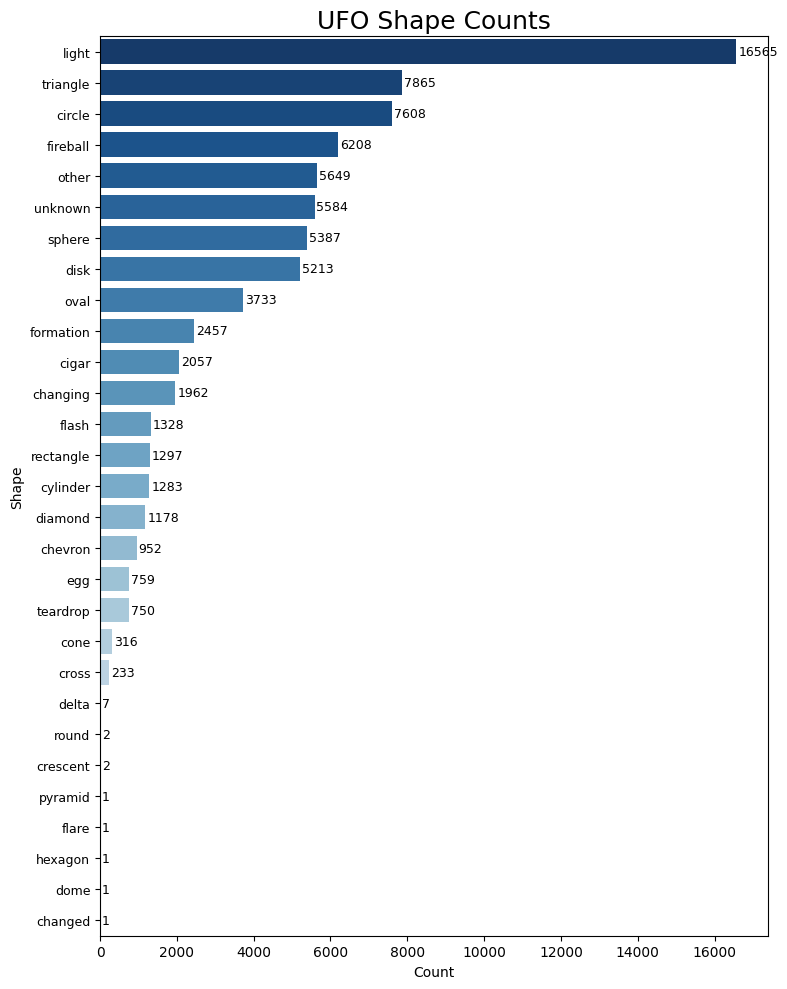

In [11]:
shape_counts = ufo_df['shape'].value_counts()

plt.figure(figsize=(8, 10))
ax = sns.barplot(
    x=shape_counts.values,
    y=shape_counts.index,
    hue=shape_counts.index,
    palette="Blues_r"
)
plt.title("UFO Shape Counts", fontsize=18)
plt.xlabel("Count")
plt.ylabel("Shape")
plt.yticks(fontsize=9)
for i, v in enumerate(shape_counts.values):
    ax.text(v + 50, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [12]:
shape_counts = ufo_df['shape'].value_counts()
rare_shapes = shape_counts[shape_counts < 200].index
ufo_df['shape'] = ufo_df['shape'].replace(rare_shapes, 'other')

In [13]:
ufo_cleaned = ufo_df.copy()

#### Drop Unused Columns

In [14]:
# Drop unused columns
ufo_cleaned = ufo_cleaned.drop(columns=["comments", "date posted","duration (hours/min)"])

The `duration (hours/min)` column was dropped because it duplicates the information in duration (seconds) but in inconsistent units. Keeping only the numeric duration simplifies analysis and ensures accurate quantitative modeling.

The `comments` column was removed since it contains unstructured text outside the scope of this study, which focuses on numerical and spatial patterns rather than linguistic content.

The `date posted` column was excluded because it reflects when a report was submitted, not when the sighting occurred. The true event timing is already captured in the `datetime` field, making date posted less meaningful for UFO pattern analysis.

### Convert `datetime` to Datetime type

Converting the datetime column to datetime format ensures consistent and accurate time-based analysis and operations across the dataset.

We found that some records in `datetime` contained timestamps using "24:00", which is invalid in Python's datetime format. The value "24:00" represents midnight of the following day, but since most libraries only accept hours from 00 to 23, these entries caused conversion errors. To handle this, all "24:00" values were replaced with "00:00"

In [15]:
ufo_cleaned["datetime"] = (ufo_cleaned["datetime"].astype(str).apply(lambda x: re.sub(r"24:00", "00:00", x)))
ufo_cleaned["datetime"] = pd.to_datetime(ufo_cleaned["datetime"])

This small adjustment preserves the temporal meaning of the records while ensuring compatibility with pandas datetime operations.

### Standardize `latitude` and `longitude`

In [16]:
def extract_numeric(value):
    """
    Extracts the first valid float-like number (with optional minus sign and decimal)
    from a string. Returns NaN if no valid number found.
    """
    if pd.isna(value):
        return None
    match = re.search(r"-?\d+\.?\d*", str(value))
    if match:
        return float(match.group())
    return None

In [17]:
ufo_cleaned["latitude"] = ufo_cleaned["latitude"].apply(extract_numeric)
ufo_cleaned["longitude"] = ufo_cleaned["longitude"].apply(extract_numeric)
# Convert to numeric just in case and drop invalid rows
ufo_cleaned["latitude"] = pd.to_numeric(ufo_cleaned["latitude"], errors="coerce")
ufo_cleaned["longitude"] = pd.to_numeric(ufo_cleaned["longitude"], errors="coerce")

In [18]:
ufo_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 78400 entries, 0 to 80331
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   datetime            78400 non-null  datetime64[ns]
 1   city                78400 non-null  object        
 2   state               72742 non-null  object        
 3   country             69001 non-null  object        
 4   shape               78400 non-null  object        
 5   duration (seconds)  78400 non-null  object        
 6   latitude            78400 non-null  float64       
 7   longitude           78400 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 5.4+ MB


To ensure all coordinate information was standardized for downstream geospatial analysis, I implemented a custom cleaning pipeline using a regex-based function:*extract_numeric* to extract valid float-like numbers from potentially messy latitude and longitude entries. This approach handled irregular formats (e.g., values containing symbols, extra spaces, or text) and safely converted all coordinates to numeric types. After cleaning, both latitude and longitude columns contained 78,400 valid float64 values, confirming that all coordinate data were successfully retained and standardized.

### Standardize `city`, `state`, and `country`

In [19]:
# Extract coordinates
coords = list(zip(ufo_cleaned["latitude"], ufo_cleaned["longitude"]))
# Batch reverse-geocode
results = rg.search(coords)
# Create geocoded DataFrame and align
geo_df = pd.DataFrame(results)
geo_df.index = ufo_cleaned.index
# Replace state & country with standardized values
ufo_cleaned["city"] = geo_df["name"]
ufo_cleaned["state"] = geo_df["admin1"]
ufo_cleaned["country"] = geo_df["cc"]

Loading formatted geocoded file...


We regenerated the `city`, `state`, and `country` columns directly from the latitude and longitude coordinates to achieve a consistent and standardized geographic representation across all records. The original text-based fields contained irregularities such as inconsistent capitalization, abbreviations, and mixed naming conventions, which made them unreliable for quantitative analysis or model training. In contrast, latitude and longitude are precise and continuous numerical values that can be used to objectively infer standardized location information through reverse geocoding. This ensures that entries with identical coordinates map to the same administrative regions, eliminating human errors and variations in naming.


In [20]:
ufo_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 78400 entries, 0 to 80331
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   datetime            78400 non-null  datetime64[ns]
 1   city                78400 non-null  object        
 2   state               78400 non-null  object        
 3   country             78400 non-null  object        
 4   shape               78400 non-null  object        
 5   duration (seconds)  78400 non-null  object        
 6   latitude            78400 non-null  float64       
 7   longitude           78400 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 5.4+ MB


## City Features Dataset

(todo)explanation of this dataset

In [21]:
city_github_url = 'https://raw.githubusercontent.com/jingyig16/ufo-sightings/refs/heads/main/new_dataset/city_features.csv'
city_df = pd.read_csv(city_github_url, low_memory=False)

In [22]:
city_df.head()

,city,city_ascii,lat,lng,country,iso2,iso3,admin_name,capital,population,id,wc_bio1,wc_bio4,wc_bio12,elevation_m,viirs_annual_ave
0,Tokyo,Tokyo,35.6870,139.7495,Japan,JP,JPN,Tōkyō,primary,37785000.0,1392685764,15.704166,769.836060,1431.0,33.0,28.124304
1,Jakarta,Jakarta,-6.1750,106.8275,Indonesia,ID,IDN,Jakarta,primary,33756000.0,1360771077,27.700001,37.598354,1958.0,6.0,32.622326
2,Delhi,Delhi,28.6100,77.2300,India,IN,IND,Delhi,admin,32226000.0,1356872604,25.170834,684.120056,730.0,214.0,67.107742
3,Guangzhou,Guangzhou,23.1300,113.2600,China,CN,CHN,Guangdong,admin,26940000.0,1156237133,22.320833,571.980041,1729.0,21.0,53.230152
4,Mumbai,Mumbai,19.0761,72.8775,India,IN,IND,Mahārāshtra,admin,24973000.0,1356226629,27.691668,182.356216,2159.0,6.0,37.921257


In [23]:
len(city_df)

48059

In [24]:
city_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48059 entries, 0 to 48058
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   city              48059 non-null  object 
 1   city_ascii        48057 non-null  object 
 2   lat               48059 non-null  float64
 3   lng               48059 non-null  float64
 4   country           48059 non-null  object 
 5   iso2              48026 non-null  object 
 6   iso3              48059 non-null  object 
 7   admin_name        47858 non-null  object 
 8   capital           15138 non-null  object 
 9   population        47808 non-null  float64
 10  id                48059 non-null  int64  
 11  wc_bio1           47484 non-null  float64
 12  wc_bio4           47484 non-null  float64
 13  wc_bio12          47484 non-null  float64
 14  elevation_m       47484 non-null  float64
 15  viirs_annual_ave  48055 non-null  float64
dtypes: float64(8), int64(1), object(7)
memor

In [25]:
city_df=city_df.rename(columns={
    "wc_bio1":"avg_annual_temp(°C)",
    "wc_bio4":"temp_seasonality",
    "wc_bio12":"annual_precipitation(mm)",
    "elevation_m":"elevation(m)"
})

(todo): explanation of features \
`temp_seasonality`:

`viirs_annual_ave`: annual average nighttime light intensity from satellite VIIRS data(unit: nW/cm²/sr)

In [26]:
city_cleaned = city_df.copy()

### Drop Unused Columns

In [27]:
city_cleaned = city_cleaned.drop(['city_ascii','iso2', 'iso3', 'admin_name', 'id', 'capital'], axis=1)

The `city_ascii` column was removed because the geographic position of each observation is already precisely defined by its latitude and longitude coordinates, and we will do standardization of city names.

The `iso2`and `iso3` columns were dropped because country information is already represented by the `country` field, while geographic location is fully captured by the `lat` and `lng` coordinates. Retaining multiple identifiers for the same attribute would introduce redundancy without adding analytical value.

The `admin_name`, `id` and `capital` columns were dropped because they contain administrative or metadata fields inherited from the original city dataset (e.g., province names, city IDs, or capital status) that are not relevant to the spatial analysis or the merging process with the UFO dataset. They were excluded to streamline the dataset and maintain focus on features directly related to location matching.

In [28]:
city_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48059 entries, 0 to 48058
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   city                      48059 non-null  object 
 1   lat                       48059 non-null  float64
 2   lng                       48059 non-null  float64
 3   country                   48059 non-null  object 
 4   population                47808 non-null  float64
 5   avg_annual_temp(°C)       47484 non-null  float64
 6   temp_seasonality          47484 non-null  float64
 7   annual_precipitation(mm)  47484 non-null  float64
 8   elevation(m)              47484 non-null  float64
 9   viirs_annual_ave          48055 non-null  float64
dtypes: float64(8), object(2)
memory usage: 3.7+ MB


### Standardize `latitude` and `longitude`



In [29]:
city_cleaned["lat"] = city_cleaned["lat"].apply(extract_numeric)
city_cleaned["lng"] = city_cleaned["lng"].apply(extract_numeric)

city_cleaned["lat"] = pd.to_numeric(city_cleaned["lat"])
city_cleaned["lng"] = pd.to_numeric(city_cleaned["lng"])

### Standardize `city`, `state`, and `country`

In [30]:
# Extract coordinates
coords = list(zip(city_cleaned["lat"], city_cleaned["lng"]))
# Batch reverse-geocode
results = rg.search(coords)
# Create geocoded DataFrame and align
geo_df = pd.DataFrame(results)
geo_df.index = city_cleaned.index
# Replace state & country with standardized values
city_cleaned["city"] = geo_df["name"]
city_cleaned["state"] = geo_df["admin1"]
city_cleaned["country"] = geo_df["cc"]

Use the same method as how we processed `city`, `state` and `country` names in `ufo_cleaned` to ensure consistency.

## Global Airports Dataset

(todo) intro to this dataset;

We include the Global Airports dataset to account for aviation activity that may influence UFO reports. Airports generate frequent aircraft traffic and night-time lighting, both of which are known sources of UFO misidentification. By incorporating accurate airport locations, we can measure each sighting's proximity to aviation infrastructure and control for these human-error factors in our analysis.

In [31]:
global_airports_github_url = 'https://raw.githubusercontent.com/jingyig16/ufo-sightings/refs/heads/main/new_dataset/world-airports.csv'
airports_df = pd.read_csv(global_airports_github_url, low_memory=False)

In [32]:
airports_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84109 entries, 0 to 84108
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 84109 non-null  int64  
 1   ident              84109 non-null  object 
 2   type               84109 non-null  object 
 3   name               84109 non-null  object 
 4   latitude_deg       84109 non-null  float64
 5   longitude_deg      84109 non-null  float64
 6   elevation_ft       69531 non-null  float64
 7   continent          44759 non-null  object 
 8   country_name       84109 non-null  object 
 9   iso_country        83841 non-null  object 
 10  region_name        84109 non-null  object 
 11  iso_region         84109 non-null  object 
 12  local_region       84092 non-null  object 
 13  municipality       79360 non-null  object 
 14  scheduled_service  84109 non-null  int64  
 15  gps_code           43697 non-null  object 
 16  icao_code          931

In [33]:
airports_df['type'].unique()

array(['large_airport', 'closed', 'medium_airport', 'small_airport',
       'seaplane_base', 'heliport', 'balloonport'], dtype=object)

In [34]:
irrelavant_types = ["balloonport", "seaplane_base","closed"]
airports_df=airports_df[~airports_df['type'].isin(irrelavant_types)]
airports_df=airports_df.drop(columns=['type'])

We removed the categories “balloonport, “seaplane_base,” and “closed” because they do not contribute meaningful aviation activity that could influence UFO sightings. Balloonports and seaplane bases operate primarily during daytime and produce minimal lighting or flight traffic. This means they are unlikely to cause people to confuse normal aircraft with UFOs, so they do not add useful information to our analysis.

In [35]:
airports_df=airports_df[['name','latitude_deg','longitude_deg']]

In [36]:
airports_df.head(5)

,name,latitude_deg,longitude_deg
0,London Heathrow Airport,51.470600,-0.461941
1,Los Angeles International Airport,33.942501,-118.407997
2,Chicago O'Hare International Airport,41.978600,-87.904800
3,John F Kennedy International Airport,40.639447,-73.779317
4,Hartsfield Jackson Atlanta International Airport,33.636700,-84.428101


## Country Education Level Dataset

(todo): intro to the dataset

In [37]:
edu_github_url = 'https://raw.githubusercontent.com/jingyig16/ufo-sightings/refs/heads/main/new_dataset/edu_cleaned.csv'
edu_df = pd.read_csv(edu_github_url, low_memory=False)

In [38]:
edu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 37 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Countries_and_areas                      202 non-null    object 
 1   Latitude                                 202 non-null    float64
 2   Longitude                                202 non-null    float64
 3   OOSR_Pre0Primary_Age_Male                202 non-null    int64  
 4   OOSR_Pre0Primary_Age_Female              202 non-null    int64  
 5   OOSR_Primary_Age_Male                    202 non-null    int64  
 6   OOSR_Primary_Age_Female                  202 non-null    int64  
 7   OOSR_Lower_Secondary_Age_Male            202 non-null    int64  
 8   OOSR_Lower_Secondary_Age_Female          202 non-null    int64  
 9   OOSR_Upper_Secondary_Age_Male            202 non-null    int64  
 10  OOSR_Upper_Secondary_Age_Female          202 non-n

To capture the cultural and socioeconomic context behind how UFO sightings are interpreted and reported, we include three national-level indicators: `Gross_Tertiary_Education_Enrollment`, `Youth_15_24_Literacy_Rate_Both`, and `Unemployment_Rate`. Prior work on UFO reporting and anomalous perception suggests that the way people describe unusual aerial phenomena, including the shape they report, is strongly influenced by cultural background, scientific literacy, and social conditions. Higher educational attainment and literacy reflect exposure to scientific reasoning and familiarity with aviation, astronomy, and satellite activity, which may shape how observers interpret ambiguous lights or objects. Meanwhile, unemployment rate serves as a proxy for broader socioeconomic conditions that may affect outdoor activity patterns, attention to the night sky, and even reporting behavior. By including this small set of culturally meaningful features, we aim to capture human-contextual factors that may influence how UFO shapes are perceived and documented.

In [39]:
edu_df=edu_df[['Latitude','Longitude','Gross_Tertiary_Education_Enrollment','Youth_15_24_Literacy_Rate_Both','Unemployment_Rate']]

## Join Dataframes

### City Features with UFO Sighting

In the city features dataset, `population`, `avg_annual_temp(°C)`, `temp_seasonality`, `annual_precipitation(mm)`, `elevation(m)`, and `viirs_annual_ave` contain missing values for some cities. If we simply merged each UFO sighting with the single nearest city, some UFO records would inherit missing feature values even though a slightly more distant nearby city has complete data.

To address this, we implemented a nearest–non-null matching procedure:

- For each UFO sighting, we identified the k nearest cities using BallTree K-nearest-neighbor search in projected coordinates.

- For each feature, we examined these candidate cities in order of distance (nearest → farther).

- We selected the closest city that actually has a valid (non-null) value for that feature.

- We also recorded the distance to the city that supplied the data, producing a meaningful measure of spatial accuracy.

This approach preserves geographic proximity while ensuring that we do not propagate missing values. It produces feature assignments that are both spatially reasonable (always taking the closest available city) and data-complete (never selecting a city with missing information if a slightly farther city has valid data). The resulting dataset is therefore more robust for downstream modeling and analysis.

In [40]:
def ufo_with_city_features(g_ufo_m, g_cities_m, features_to_match, k=5):
    """
    Find the closest city (within k candidates) that has non-null values for each feature
    and compute the distance to the specific fallback city used for that feature.
    """
    # Extract (x, y) coordinates for KNN search
    city_coords = np.vstack([g_cities_m.geometry.x, g_cities_m.geometry.y]).T
    ufo_coords  = np.vstack([g_ufo_m.geometry.x, g_ufo_m.geometry.y]).T
    # Build a BallTree from city coordinates
    tree = BallTree(city_coords)
    # Query k nearest cities for each UFO point
    # dists[i, j] = distance from UFO i to its j-th nearest city
    # idxs[i, j]  = row index in g_cities_m of that j-th nearest city
    dists, idxs = tree.query(ufo_coords, k=k)

    result = g_ufo_m.copy()

    feature_dist_cols = []  #To store temporary distance columns here (one per feature).
    # Find fallback for each feature
    for col in features_to_match:
        chosen_vals = []
        chosen_dists = []

        for u in range(len(idxs)):
            candidates = idxs[u]       # k nearest city indices
            distances = dists[u]       # the distances from u-th UFO to each of the k cities.
            found = False
            for rank, city_idx in enumerate(candidates):
                val = g_cities_m.iloc[city_idx][col]
                if pd.notnull(val):
                    chosen_vals.append(val)               # record fallback feature values
                    chosen_dists.append(distances[rank])  # record fallback distance
                    found = True
                    break
            if not found:
                chosen_vals.append(np.nan)
                chosen_dists.append(np.nan)
        # Write chosen values to result
        result[col] = chosen_vals
        # Store distance column temporarily
        dist_col_name = f"__dist_{col}"
        result[dist_col_name] = chosen_dists
        feature_dist_cols.append(dist_col_name)

    # final dist_m: max distance across all fallback distances for this UFO record
    result["dist_m"] = result[feature_dist_cols].max(axis=1)
    # Remove temporary per-feature dist columns
    result = result.drop(columns=feature_dist_cols)

    return result

In [41]:
# A GeoDataFrame is like a normal DataFrame but supports spatial operations.
# geometry=gpd.points_from_xy(...): Converts each (longitude, latitude) pair into a Point geometry object since GeoPandas requires a geometry column to do spatial joins.
# crs="EPSG:4326": Sets the coordinate reference system (CRS) to the standard GPS coordinates(EPSG:4326)
g_ufo   = gpd.GeoDataFrame(ufo_cleaned, geometry=gpd.points_from_xy(ufo_cleaned.longitude, ufo_cleaned.latitude), crs="EPSG:4326")
g_cities= gpd.GeoDataFrame(city_cleaned, geometry=gpd.points_from_xy(city_cleaned.lng, city_cleaned.lat), crs="EPSG:4326")
# EPSG 3857 is a metric projection, meaning its units are meters.
g_ufo_m    = g_ufo.to_crs(3857)
g_cities_m = g_cities.to_crs(3857)

In [42]:
features_to_match= [
    "population",
    "avg_annual_temp(°C)",
    "temp_seasonality",
    "annual_precipitation(mm)",
    "elevation(m)",
    "viirs_annual_ave"
]
joined = ufo_with_city_features(g_ufo_m, g_cities_m, features_to_match, k=5)

#### Processing the joined dataframe

We want to attach city-level climate and environmental information (like temperature, precipitation, elevation, and nighttime light) to each UFO sighting.
Since these climate variables are measured at the city level, which represents a fairly large surrounding area, we assume that a city's climate represents the conditions within 100 km around that (latitude,longitude).
Based on this assumption, we link each UFO sighting to the nearest city, but only if it is within 100 km.
This way, the environmental information we attach to each sighting is accurate and geographically relevant.

In [43]:
# Filter out far matches > 100 km)
joined = joined[joined['dist_m'] <= 100000]
joined = joined.drop(columns=['dist_m'])

We drop the `geometry` column because it is only required by GeoPandas for spatial operations, and once the spatial matching is complete, the geometry objects are no longer needed.

In [44]:
joined = joined.drop(columns=['geometry'])

In [45]:
joined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76559 entries, 0 to 80331
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   datetime                  76559 non-null  datetime64[ns]
 1   city                      76559 non-null  object        
 2   state                     76559 non-null  object        
 3   country                   76559 non-null  object        
 4   shape                     76559 non-null  object        
 5   duration (seconds)        76559 non-null  object        
 6   latitude                  76559 non-null  float64       
 7   longitude                 76559 non-null  float64       
 8   population                76559 non-null  float64       
 9   avg_annual_temp(°C)       76559 non-null  float64       
 10  temp_seasonality          76559 non-null  float64       
 11  annual_precipitation(mm)  76559 non-null  float64       
 12  elevation(m)           

### Airports with UFO Sighting

To quantify how close each UFO sighting occurred to major airports, we calculated the distance from every sighting to its nearest airport using airport latitude/longitude data. We built a BallTree with the haversine metric to correctly compute great-circle distances on Earth and identified the closest airport for each UFO point. The resulting feature, `dist_to_nearest_airport(m)`, indicates how near the sighting was to an airport, helping us evaluate whether airport lighting or aircraft operations might contribute to some reports.


In [46]:
airport_coords = np.vstack([airports_df["longitude_deg"].values,airports_df["latitude_deg"].values]).T
ufo_coords = np.vstack([joined["longitude"].values,joined["latitude"].values]).T
# Convert degrees → radians for haversine
airport_rad = np.radians(airport_coords)
ufo_rad = np.radians(ufo_coords)
# Build BallTree for nearest-neighbor search
tree = BallTree(airport_rad, metric='haversine')
# Query nearest airport record for each UFO sighting
dists_rad, idxs = tree.query(ufo_rad, k=1)
earth_radius_m = 6371000  # meters
# Calculate the distance
dists_m = dists_rad[:, 0] * earth_radius_m
joined["dist_to_nearest_airport(m)"] = dists_m

### Country Education Level with UFO Sighting

In [47]:
edu_coords = np.vstack([edu_df["Longitude"].values, edu_df["Latitude"].values]).T
ufo_coords = np.vstack([joined["longitude"].values, joined["latitude"].values]).T
# Convert degrees → radians for haversine
edu_rad = np.radians(edu_coords)
ufo_rad = np.radians(ufo_coords)
# Build BallTree for nearest-neighbor search
tree = BallTree(edu_rad, metric='haversine')
# Query nearest education record for each UFO sighting
dists, idxs = tree.query(ufo_rad, k=1)
# Add the matched columns
joined["Gross_Tertiary_Education_Enrollment"] = edu_df["Gross_Tertiary_Education_Enrollment"].iloc[idxs[:,0]].values
joined["Youth_15_24_Literacy_Rate_Both"] = edu_df["Youth_15_24_Literacy_Rate_Both"].iloc[idxs[:,0]].values
joined["Unemployment_Rate"] = edu_df["Unemployment_Rate"].iloc[idxs[:,0]].values

In [48]:
joined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76559 entries, 0 to 80331
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   datetime                             76559 non-null  datetime64[ns]
 1   city                                 76559 non-null  object        
 2   state                                76559 non-null  object        
 3   country                              76559 non-null  object        
 4   shape                                76559 non-null  object        
 5   duration (seconds)                   76559 non-null  object        
 6   latitude                             76559 non-null  float64       
 7   longitude                            76559 non-null  float64       
 8   population                           76559 non-null  float64       
 9   avg_annual_temp(°C)                  76559 non-null  float64       
 10  temp_seasonalit

# Part 3: Exploratory Data Analysis


## Country-Level Shape Distributions

To examine whether country-level features carry predictive value for UFO shape classification, we begin by analyzing how reported shapes vary **across countries**.

### UFO Sighting Frequency across Countries

As a first step, we examine the geographic distribution of UFO sighting frequency. Understanding where reports are concentrated is essential, because cross-country differences in reporting activity may reflect underlying social or environmental conditions that also affect the types of shapes people describe. Establishing this baseline helps contextualize later analyses of shape distributions and ensures that any observed shape patterns are interpreted in light of the underlying reporting landscape.


In [ ]:
# Assign a weight of 1 to every sighting
plot_df=joined.copy()
plot_df["intensity"] = 1
heat_data = plot_df[["latitude", "longitude", "intensity"]].values.tolist()

# Custom bright heatmap color gradient
custom_gradient = {0.0: "#0000FF",0.4: "#00FFFF",0.6: "#00FF00",0.8: "#FFFF00",1.0: "#FF0000",   }

# Create a bounded world map
m = folium.Map(location=[20, 0],zoom_start=2,min_zoom=2,max_bounds=True,tiles="CartoDB dark_matter",
               width="85%",height="85%",control_scale=False)
# Add the heatmap layer
HeatMap(heat_data,radius=18,blur=12,min_opacity=0.3,max_zoom=4,gradient=custom_gradient).add_to(m)

# Display the map
m

The global heatmap of UFO sighting frequency shows clear geographic differences. North America and parts of Europe report many more sightings, while large areas of Africa and South America report very few. These differences likely reflect country-level factors that affect how often people submit reports, such as education level, literacy, internet access, and the strength of online reporting systems. Countries with better access to information and communication tools may contribute more sightings to databases like NUFORC, regardless of the true underlying rate of unusual events.

This pattern is important for modeling because it shows that country-level features influence not only where sightings occur but also how likely they are to be reported. These social and geographic factors may also affect how people interpret and describe what they see. As a result, such features may provide useful predictive signal for UFO shape classification and help us better understand differences in reporting behavior across countries.

### UFO Shape Distributions within each Country

The global distribution of sighting counts indicates that reporting frequency is strongly shaped by country-specific factors. If these factors influence whether a sighting is reported, they may also influence how it is reported. To test this idea, we turn to the normalized distribution of UFO shapes across countries.

In [49]:
# Count sightings per shape per country
df_counts = (joined.groupby(['country', 'shape']).size().reset_index(name='count'))

# Normalize within each country
totals = df_counts.groupby('country')['count'].sum().reset_index(name='total')
df_norm = df_counts.merge(totals, on='country')
df_norm['pct'] = df_norm['count'] / df_norm['total']

# Pivot to matrix
heatmap_df = df_norm.pivot(index='country',columns='shape',values='pct').fillna(0)

# Plot
fig = px.imshow(heatmap_df, color_continuous_scale="Viridis",aspect="auto",height=1000,width=800,
                title="UFO Shape Distribution Across 158 Countries (Normalized)")

fig.update_layout(xaxis_title="UFO Shape",yaxis_title="Country",)
fig.show()


This heatmap shows the normalized distribution of UFO shapes across 158 countries.
- Each row = country
- Each column = UFO shape
- Each cell = percentage of that shape within that country's sightings

Because each row is normalized, bright (yellow) cells indicate a shape that is unusually dominant within that country.

The heatmap shows clear cross-country variance in the distribution of UFO shapes.
Since different countries exhibit different dominant shapes,
this indicates that country-level features carry useful information about the expected UFO shape.
